# Merge and normalize dataset

อนุมานว่า ในแหล่งที่มาของ 2 dataset นี้ถูก clean ให้อยู่ในสภาพที่พร้อมใช้งานแล้ว

สำหรับ **Phase 3 : Classification** เรายังไม่สามารถใช้งานได้ทันที เพราะแต่ละ dataset มีรูปแบบและปริมาณข้อมูลไม่เท่ากัน

In [1]:
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
# Setup Thai font, should be put on first cell of the notebook.
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

## Download dataset

เราใช้ library `datasets` ในการดาวน์โหลดจาก Hugging Face

In [3]:
from datasets import load_dataset

# prachatai67k dataset (baseline)
pct_ds = load_dataset("szzs1693/prachathai67k", "labeled")

# thaipbs-news dataset (scraped)
tpbs_ds = load_dataset("szzs1693/nlp-thaipbs-news")

โหลด dataset เข้าสู่ pandas

In [4]:
pct_df = pct_ds['train'].to_pandas()
tpbs_df = tpbs_ds['train'].to_pandas()

## Explore dataset

- ดูจำนวน records และ columns
- ดูตัวอย่าง data
- ดู schema โครงสร้างของ dataset

### Prachathai

In [5]:
pct_df.head()

,url,date,title,body_text,politics,human_rights,quality_of_life,international,social,environment,economics,culture,labor,national_security,ict,education
0,https://prachatai.com/print/42,2004-08-24 14:31:00,"นักวิจัยหนุน ""แม้ว"" เปิด ""จีเอ็มโอ""",ประชาไท --- 23 ส.ค.2547 นักวิจัยฯ ชี้นโยบายจี...,0,0,0,0,0,1,0,0,0,0,0,0
1,https://prachatai.com/print/41,2004-08-24 14:22:00,ภาคประชาชนต้านเปิดเสรีจีเอ็มโอ,ประชาไท- 23 ส.ค.2547 นักวิชาการ ภาคประชาชน จ...,0,0,0,0,0,1,0,0,0,0,0,0
2,https://prachatai.com/print/43,2004-08-24 15:17:00,จุฬาฯ ห่วงจีเอ็มโอลามข้าวไทย,นโยบายที่อนุญาตให้ปลูกร่วมกับพืชอื่นได้นั้นถื...,0,0,0,0,0,1,0,0,0,0,0,0
3,https://prachatai.com/print/45,2004-08-24 15:58:00,ฟองสบู่การเมืองแตก ทักษิณหมดกึ๋น ชนชั้นกลางหมด...,ประชาไท -- 23 ส.ค. 47 ขาประจำทักษิณ ฟันธง ฟอง...,1,0,0,0,0,0,0,0,0,0,0,0
4,https://prachatai.com/print/47,2004-08-24 16:10:00,กอต.เสนอเลิกถนนคลองลาน-อุ้มผาง,ประชาไท-23 ส.ค.47 คณะกรรมการอนุรักษ์ ผืนป่าตะ...,0,0,0,0,0,1,0,0,0,0,0,0


In [6]:
pct_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67889 entries, 0 to 67888
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   url                67889 non-null  str           
 1   date               67889 non-null  datetime64[us]
 2   title              67889 non-null  str           
 3   body_text          67889 non-null  str           
 4   politics           67889 non-null  int8          
 5   human_rights       67889 non-null  int8          
 6   quality_of_life    67889 non-null  int8          
 7   international      67889 non-null  int8          
 8   social             67889 non-null  int8          
 9   environment        67889 non-null  int8          
 10  economics          67889 non-null  int8          
 11  culture            67889 non-null  int8          
 12  labor              67889 non-null  int8          
 13  national_security  67889 non-null  int8          
 14  ict              

เราจะสังเกตเห็นได้ว่า dataset ของ prachathai เป็น dataset แบบ **multi-label classification** โดยมีข้อมูลทั้งหมด 67889 รายการ ประกอบด้วยคอลัมน์ url, date, title, body_text (ข้อความ) และ 12 หมวดหมู่ เป็น label ดังนี้

* `การเมือง` - politics
* `สิทธิมนุษยชน` - human rights
* `คุณภาพชีวิต` - quality of life
* `ต่างประเทศ` - international
* `สังคม` - social
* `สิ่งแวดล้อม` - environment
* `เศรษฐกิจ` - economics
* `วัฒนธรรม` - culture
* `แรงงาน` - labor
* `ความมั่นคง` - national security
* `ไอซีที` - ICT
* `การศึกษา` - education

แต่ละ label ถูก encode เป็น one-hot encoding ถ้าข่าวนี้มี label ที่กำหนด column นั้นจะเป็น 1 ไม่เช่นนั้นจะเป็น 0

เนื่องจากเป็น multi-label เราเลยยังไม่รู้ว่าสุดท้ายแต่ละ label มีรายการเท่าไหร่ จำเป็นต้องดำเนินการต่อไป

### ThaiPBS

In [7]:
tpbs_df.head()

,url,title,categoryName,abstract,publishedTime,tags,content_html,content_text
0,https://www.thaipbs.or.th/news/content/355884,"""อาร์เจนตินา"" ประตูสู่ ลาตินอเมริกา โอกาส ""ยา...",เศรษฐกิจ,,2025-09-01 03:38:00,"[อาร์เจนตินา, ส่งออกสินค้าไทย, ตลาดส่งออกไทย, ...","<p><strong><em>""บัวโนสไอเรส"" เมืองหลวงของอาร์เ...","""บัวโนสไอเรส"" เมืองหลวงของอาร์เจนตินา ตั้งอยู่..."
1,https://www.thaipbs.or.th/news/content/356014,“เนื้อโคขุน” สุรินทร์ ของดีเมืองไทย รสชาตินุ่ม...,เศรษฐกิจ,,2025-09-02 04:43:00,"[เนื้อสุรินทร์, เนื้อโคขุน, เนื้อโค, โคขุน, จั...",<p><em><strong>“สีแดงอมชมพู ลายไขมันแทรกสวย” เ...,“สีแดงอมชมพู ลายไขมันแทรกสวย” เมื่อปรุงสุกจะได...
2,https://www.thaipbs.or.th/news/content/356017,เปิดนำเข้าพ่อแม่พันธุ์ไก่ “รมว.เกษตรฯ”ถก บอร์ด...,เศรษฐกิจ,“รมว.เกษตรฯ” ถกบอร์ดไข่ไก่ ยันผู้ประกอบการขอนำ...,2025-09-01 08:40:00,"[ไข่ไก่, พ่อพันธุ์แม่พันธุ์ไก่, นำเข้าพ่อแม่พั...",<p>วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร...,วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร รม...
3,https://www.thaipbs.or.th/news/content/356047,พณ.ดันอาเซียน–อินเดีย ทบทวนข้อตกลงการค้าเปิดทา...,เศรษฐกิจ,พาณิชย์ ถกรมว.อาเซียน-อินเดีย ดันทบทวนความตกลง...,2025-09-02 05:40:40,"[ความตกลงการค้าสินค้าอาเซียน–อินเดีย, อาเซียนอ...",<p>วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ...,วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ์ ร...
4,https://www.thaipbs.or.th/news/content/356067,ไทยส่งออกสัตว์น้ำได้ฉลุย หลังสหรัฐฯประกาศผ่านเ...,เศรษฐกิจ,ข่าวดี สหรัฐฯ ประกาศ ไทยผ่านเกณฑ์มาตรฐาน MMPA ...,2025-09-02 08:59:13,"[กรมประมง, ส่งออกสัตว์น้ำ, สินค้าสัตว์น้ำไทย, ...",<p>วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบด...,วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบดีกร...


In [8]:
tpbs_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype        
---  ------         --------------  -----        
 0   url            1200 non-null   str          
 1   title          1200 non-null   str          
 2   categoryName   1200 non-null   str          
 3   abstract       1200 non-null   str          
 4   publishedTime  1200 non-null   datetime64[s]
 5   tags           1200 non-null   object       
 6   content_html   1200 non-null   str          
 7   content_text   1200 non-null   str          
dtypes: datetime64[s](1), object(1), str(6)
memory usage: 21.1+ MB


In [9]:
# หาจำนวนของแต่ละหมวดหมู่
tpbs_df['categoryName'].value_counts()

categoryName
เศรษฐกิจ    400
การเมือง    400
สังคม       400
Name: count, dtype: int64

เราจะสังเกตเห็นได้ว่า dataset ของ Thai PBS เป็น dataset แบบ **label classification** ปกติ โดยมีข้อมูลทั้งหมด 1200 รายการ ประกอบด้วยคอลัมน์ url, title, categoryName (เศรษฐกิจ, การเมือง, สังคม), abstract, publishedTime, tags, content_html, content_text

## Normalize Prachathai Labels

(ดัดแปลงมาจาก https://github.com/lemasc/prachathai-67k/blob/master/exploration.ipynb)

จากตัวอย่างข่าวด้านบน ทำให้เราพอสรุปได้ว่า แต่ละข่าว อาจมีหลาย label เช่น ข่าว ๆ หนึ่งอาจมีทั้งเรื่องเศรษฐกิจและการเมืองด้วยกัน หากเราไม่แยก label ให้ถูกต้อง จะทำให้การทำ classification ของหัวข้อนั้นสับสนได้ เพราะในข่าวมีคำที่คลุมเครือ เป็นต้น ด้วยเหตุนี้เอง เราจึงต้องเลือกกรองเฉพาะข่าวที่มั่นใจเท่านั้น

เราจะลองหาความเชื่อมโยงของแต่ละ label กันก่อน

In [10]:
# เลือกเฉพาะ column label ของแต่ละข่าว เพื่อใช้คำนวณในภายหลัง
pct_encoded_labels = pct_df.iloc[:,4:]
all_labels = pct_encoded_labels.columns
print(all_labels)

pct_encoded_labels.sample(n=3, random_state=1)

Index(['politics', 'human_rights', 'quality_of_life', 'international',
       'social', 'environment', 'economics', 'culture', 'labor',
       'national_security', 'ict', 'education'],
      dtype='str')


,politics,human_rights,quality_of_life,international,social,environment,economics,culture,labor,national_security,ict,education
30985,1,0,0,0,0,0,0,0,0,0,0,0
34754,0,1,0,1,0,0,0,0,0,0,1,0
45308,0,0,0,0,0,0,0,1,0,0,0,1


In [11]:
# รวมทุก label ในแกน X (แนวตั้ง) เพื่อนับว่าแต่ละหมวดมีจำนวนเท่าไหร่
pct_count_label = pct_encoded_labels.sum(axis=0).reset_index()
# เปลี่ยนชื่อ col
pct_count_label.columns = ['label','count']
# นับ percent สัดส่วน
pct_count_label['per'] = pct_count_label['count'] / pct_count_label['count'].sum()
pct_count_label.sort_values('per', ascending=False, inplace=True)

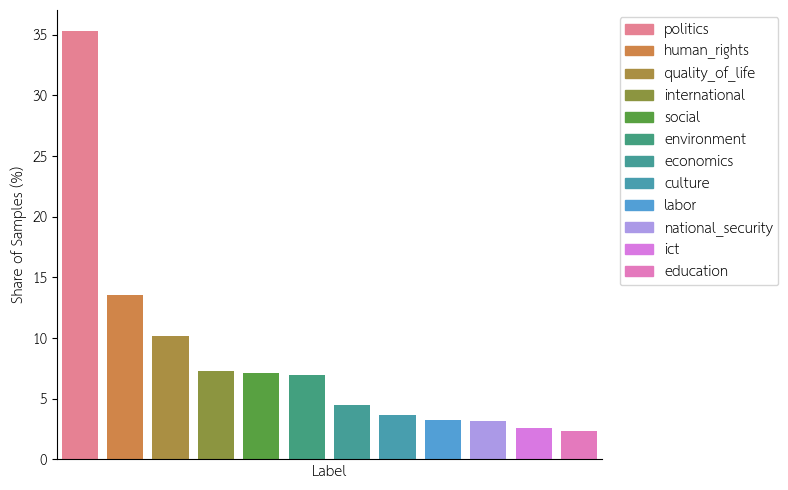

,label,count,per
0,politics,39095,0.352690
1,human_rights,15030,0.135591
2,quality_of_life,11308,0.102014
3,international,8094,0.073019
4,social,7892,0.071197
5,environment,7693,0.069401
6,economics,5000,0.045107
7,culture,4065,0.036672
8,labor,3630,0.032748
9,national_security,3542,0.031954


In [12]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(data=pct_count_label, x='label', y='per', hue='label', dodge=False)

# Convert y-axis to percentage
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{round(x*100)}'))

# Labels
plt.xlabel('Label')
plt.ylabel('Share of Samples (%)')
plt.xticks([])

# Add custom legend
colors = ax.patches

import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color=colors[i].get_facecolor(), label=all_labels[i])
    for i in range(len(all_labels))
]

plt.legend(handles=legend_handles, title=None, bbox_to_anchor=(1.02, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

pct_count_label

จำนวนข่าวหมวด **การเมือง** มีสัดส่วนที่มากที่สุด เมื่อเทียบกับหมวดอื่น ๆ รองลงมาเป็นข่าว **สิทธิมนุษยชน** และ **คุณภาพชีวิต**

แต่จากข้อมูลนี้เพียงลำพัง ยังไม่สามารถบอกได้ว่าแต่ละหมวดมีความสัมพันธ์กันอย่างไร

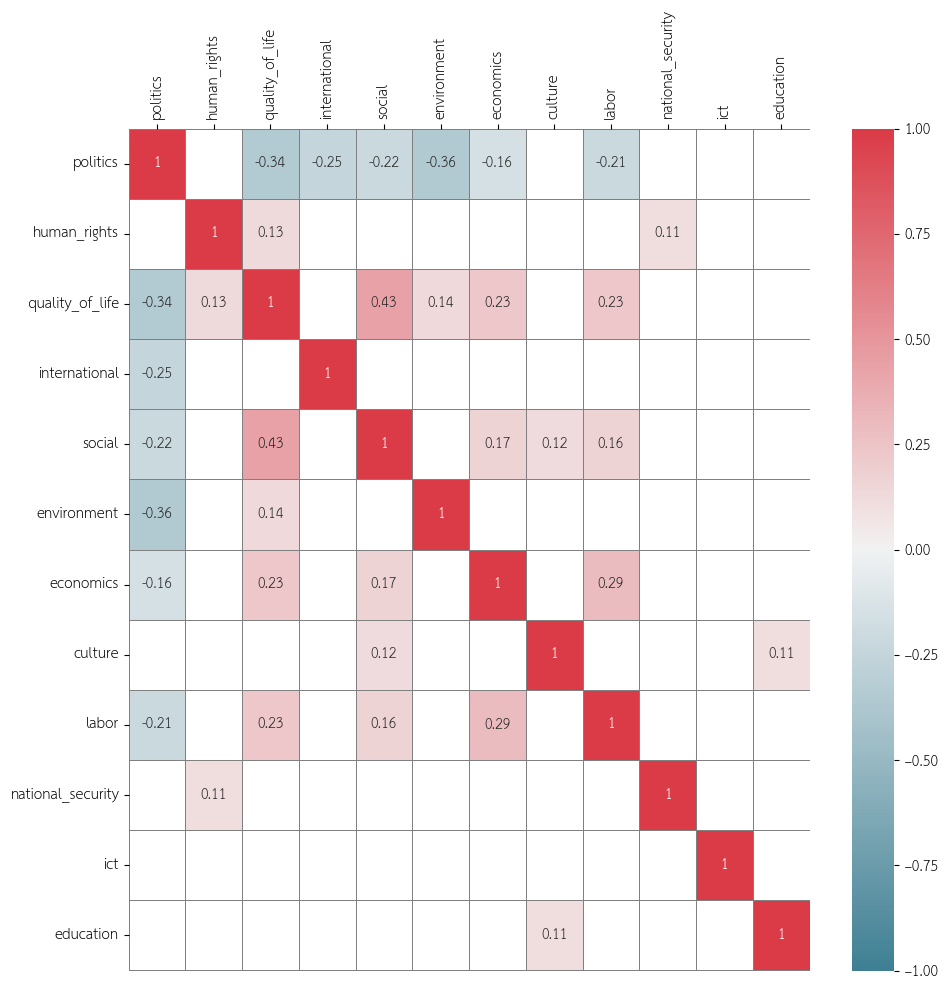

In [13]:
# คำนวณ Correlation Matrix ระหว่าง 2 label
# ยิ่งเข้าใกล้ 1 หรือ -1 แปลว่าเกี่ยวข้องมาก

plt.figure(figsize=(10,10))

corr_threshold = 0.1 # ปรับค่าได้

corr = np.corrcoef(pct_encoded_labels.to_numpy().T)
corr = np.where((corr > corr_threshold) | (corr < -corr_threshold), corr, np.nan)
ax = sns.heatmap(corr, yticklabels=all_labels,           
            cmap=sns.diverging_palette(220, 10, as_cmap=True),
            linewidths=0.5, linecolor='gray',
            vmin=-1, vmax=1, annot=True)
ax.xaxis.tick_top()
ax.set_xticklabels(all_labels, rotation=90)
plt.tight_layout()
plt.show()
plt.show()

จากกราฟด้านบน ทำให้เราสังเกตความเกี่ยวข้องของแต่ละหมวดหมู่ใน Dataset นี้ได้ ถ้าเราโฟกัสเฉพาะ 3 หมวดที่เรามีใน Thai PBS จะได้ว่า

- ข่าว **การเมือง (politics)** แทบจะเกี่ยวข้องกับข่าวในทุกหมวด ดังนั้นควรทำทีหลังสุด (หยิบเฉพาะข่าวการเมืองเพียว ๆ)
- ข่าว **สังคม (social)** มีความเกี่ยวข้องกับข่าว **คุณภาพชีวิต (corr=0.43)** มากกว่าข่าว **เศรษฐกิจ (corr=0.17)** และข่าว **แรงงาน (corr=0.16)**
- ข่าว **เศรษฐกิจ (economics)** เกี่ยวข้องกับข่าว **แรงงาน (corr=0.29)** และข่าว **คุณภาพชีวิต (corr=0.23)** ในสัดส่วนที่ไม่ต่างกันอย่างมีนัยสำคัญ

ดังที่เคยบอกไปก่อนหน้านี้ การจัดกลุ่ม เราจะเลือกเฉพาะข่าวที่มีเฉพาะ **หมวดที่ตรงกันเท่านั้น และไม่มีหมวดอื่นเลย** เช่น ถ้าข่าวนี้มีหมวดการเมือง แต่ติดหมวดอื่นที่เรากำลังทำเช่นสังคมด้วย ก็ไม่ควรหยิบมา เพราะอาจทำให้ Model สับสน

หมวดที่คลุมเครือเป็นหมวด **คุณภาพชีวิต** เนื่องจากหมวดนี้เกี่ยวข้องกับ **สังคม** มากกว่า เราจะเริ่มจัดกลุ่มหมวดนี้ก่อน 

In [14]:
# function to filter by labels easily

def filter_pct_df(
    allow_labels: list[str],
    exclude_df: pd.DataFrame | None = None,
) -> pd.DataFrame:
    """
    Return rows where:
    - At least one of `allow_labels` == 1
    - All other labels == 0
    - Optionally exclude rows present in `exclude_df`
    """

    # Must have at least one allowed label
    allow_mask = pct_df[allow_labels].eq(1).any(axis=1)

    # All other labels must be 0
    other_labels = [l for l in all_labels if l not in allow_labels]
    if other_labels:
        other_mask = pct_df[other_labels].eq(0).all(axis=1)
    else:
        other_mask = True

    mask = allow_mask & other_mask

    result = pct_df[mask]

    # Optional exclusion
    if exclude_df is not None:
        result = result.drop(index=exclude_df.index, errors="ignore")

    return result

In [15]:
# 1: จัดกลุ่มหมวด สังคม โดยเลือกข่าวที่มีหมวด สังคม / คุณภาพชีวิต แต่ไม่มีหมวดอื่นเลย
pct_labels_soci = ["social", "quality_of_life"]
pct_df_soci = filter_pct_df(pct_labels_soci)
print(pct_df_soci.shape)

# คำสั่งนี้เลือกเฉพาะ column title, body_text **และทุกอย่างใน list pct_labels_soci** มาแสดง
pct_df_soci[['title', 'body_text', *pct_labels_soci]]

(2287, 16)


,title,body_text,social,quality_of_life
2436,ปากคำแก๊งหน้าดารา : อันธพาลกวนเมือง หรือ?,คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้ง...,1,1
4526,ขึ้นค่าโดยสารรถร่วมขสมก.อีก 1บาท เริ่ม15 ก.ค.,กรุงเทพฯ 30 มิ.ย.48\tนายปิยะพันธ์ จัมปาสุต อธิ...,0,1
8600,"หนังสือดีที่พันธมิตรฯ และ ทรท. ควรอ่าน : ""อนุ...","""อนุสาวรีย์ประชาธิปไตยกับความหมายที่มองไม่เห็น...",1,0
8894,"สัมภาษณ์พิเศษ สมเกียรติ ตั้งกิจวานิชย์: ขอ ""ท...",บ่อยครั้งที่เรานั่งกดรีโมททีวีไปมาระหว่างช่องน...,1,1
9399,ประมวล เพ็งจันทร์ กับประสบการณ์นักเดินทางแห่งจ...,เรื่องราวมหัศจรรย์ของนักวิชาการมหาวิทยาลัยเที่...,1,0
...,...,...,...,...
67796,คมส.เร่งมติสมัชชาสุขภาพภายใน 1 ปี เชื่อมทุกพรร...,กก.ขับเคลื่อนฯ ยกระดับ 77 มติสมัชชาสุขภาพแห่งช...,0,1
67803,เสียงคนรุ่นใหม่-สู่กลไกสมัชชาสุขภาพแห่งชาติ,เด็กและเยาวชนมีความสำคัญในการกำหนดทิศทางประเทศ...,0,1
67818,109 องค์กร ร้อง รบ. ดันนโยบายสวัสดิการเงินอุดห...,เครือข่ายการขับเคลื่อนนโยบายสวัสดิการเงินอุดหน...,0,1
67836,'ผ่าตัดวันเดียวกลับ' บรรลุเป้า 9 เดือนลดวันนอน...,สปสช. เผย 'ผ่าตัดวันเดียวกลับ' บรรลุเป้า 9 เดื...,1,1


In [16]:
# 2: จัดกลุ่มหมวด เศรษฐกิจ โดยเลือกข่าว เศรษฐกิจ / แรงงาน / คุณภาพชีวิต แต่ต้องไม่ซ้ำกับ df ก่อนหน้านี้
pct_labels_econ = ["economics", "labor", "quality_of_life"]
pct_df_econ = filter_pct_df(pct_labels_econ, exclude_df=pct_df_soci)
print(pct_df_econ.shape)

pct_df_econ[['title', 'body_text', *pct_labels_econ]]

(1801, 16)


,title,body_text,economics,labor,quality_of_life
10034,"สัมภาษณ์ : สหภาพแรงงานแรกของภาคเหนือ ""ยังอยู่""...","\n \n""ประชาไท"" คุยกับที่ปรึกษาสหภาพแรงงานแห่งแ...",0,1,0
10711,กรรมกรทั่วโลกจงรวมตัวกัน เพื่อฮั้วขึ้นค่าแรงระ...,"งานชิ้นนี้เป็นหนึ่งในชุด ""การแสวงหาทางเลือกใหม...",1,1,0
10721,"""แรงงานนอกระบบ"" ยื่นหนังสือกรรมการสิทธิฯ ชี้ยั...",แรงงานนอกระบบในประเทศไทย ต้องเผชิญกับการถูกละเ...,0,1,0
10752,จีนทวงสัญญาสี่เหลี่ยมเศรษฐกิจ ทัพใหญ่บุกเหนือร...,จับตาทัพสื่อมวลชนจีนครึ่งร้อยบุกเหนือ ล่องน้ำ...,1,0,0
10769,"รายงาน : เมื่อแรงงานไทยร่วม ""สมานฉันท์"" ปกป้อง...",\n\nถามใจผู้ร่วมกับคณะกรรมการสมานฉันท์แรงงานไท...,0,1,0
...,...,...,...,...,...
67660,จี้ 'ประยุทธ์' เร่งแก้ปัญหาของผู้ค้าหาบเร่แผงล...,เครือข่ายแผงลอยไทยเพื่อการพัฒนาที่ยั่งยืนและนั...,1,0,1
67682,รายได้ยามชราภาพของข้าราชการน้อยไปจริงหรือ ?,1.เกริ่นนำ \n1.1 พวกเราคงได้ยินข่าวข้าราชการบำ...,1,0,1
67757,มูลนิธิเพื่อผู้บริโภคเผยปีนี้พบการร้องเรียนเรื...,มูลนิธิเพื่อผู้บริโภคเปิดเผยสถานการณ์ผู้บริโภค...,1,0,1
67816,ทำไมคนงานถึงชุมนุมเรียกร้อง? หลัง ก.แรงงานฯ เต...,แรงงาน 101 นักวิชาการชี้ช่วงปลายปีคือฤดูกาลที่...,1,1,1


In [17]:
# 3: จัดกลุ่มหมวด การเมือง
pct_labels_poli = ["politics"]
pct_df_poli = filter_pct_df(pct_labels_poli)
print(pct_df_poli.shape)

pct_df_poli[['title', 'body_text', 'date',  *pct_labels_poli]]

(24341, 16)


,title,body_text,date,politics
3,ฟองสบู่การเมืองแตก ทักษิณหมดกึ๋น ชนชั้นกลางหมด...,ประชาไท -- 23 ส.ค. 47 ขาประจำทักษิณ ฟันธง ฟอง...,2004-08-24 15:58:00,1
6,ชนชั้นกลางในความหมายของ เกษียร เตชะพีระ,รศ. เกษียร เตชะพีระ กล่าวอธิบายความหมายของชนช...,2004-08-24 16:02:00,1
4722,"ครม.เรียกเงินคืนสำนักงบฯ 50,000 ล้าน",ประชาไท-5 กค. 48 คณะรัฐมนตรีเรียกงบประมาณคืนสำ...,2005-07-06 16:37:00,1
4723,"""หมอแว""หยุดกิจกรรมประชาสังคมลุยหาเสียงส.ว.",[1]นายแพทย์แวมาหะดี แวดาโอ๊ะ อดีตจำเลยคดีเจไอ...,2005-07-14 14:26:00,1
4724,เตือนธุรกิจเร่งปรับตัว หลังผู้บริโภครัดเข็มขัด...,"กรุงเทพฯ-14 ก.ค.48 ""เดิมที่เคยคาดว่า การบริโภค...",2005-07-16 09:33:00,1
...,...,...,...,...
67850,เกษียร เตชะพีระ : ทำไมประเทศกูถึงมี “ลัทธิชังช...,\n\n“พูดให้ถึงที่สุด คนที่ถูกกล่าวหาว่าเป็นพวก...,2018-11-12 21:32:00,1
67851,EU แจงพร้อมร่วม หากไทยชวนมาสังเกตการณ์เลือกตั้...,สหภาพยุโรปยันไม่ได้เตรียมการลงพื้นที่สังเกตการ...,2018-11-12 20:04:00,1
67855,ใบตองแห้ง: Elite เสื่อมหนีตรวจสอบ,ดูเหมือนผมจะเป็นเสียงข้างน้อยในข้างน้อย ที่เห็...,2018-11-13 12:20:00,1
67871,ใบตองแห้ง: ตู่หน้าบางสังคมโง่,ลุงตู่ของคนชั้นกลางในเมืองเนี่ย เป็นคนมีเสน่ห์...,2018-11-14 12:39:00,1


### Downsample Prachathai articles

เราพบว่า แม้จะจัดกลุ่มได้แล้ว สัดส่วนของข่าวการเมืองยังมีจำนวนเยอะกว่าเมื่อเทียบกับหมวดอื่น ๆ ถ้านำไป train โดยตรงจะเกิด bias ได้

In [18]:
pct_filtered_groups = {
    "social": pct_df_soci,
    "economics": pct_df_econ,
    "politics": pct_df_poli
}

for group in pct_filtered_groups:
    df = pct_filtered_groups[group]
    print(f"Group {group} has shape:", df.shape)

Group social has shape: (2287, 16)
Group economics has shape: (1801, 16)
Group politics has shape: (24341, 16)


สำหรับหมวดอื่น ๆ ที่มีจำนวนข่าวเยอะกว่า เราจะใช้วิธี downsample หรือก็สุ่มตัวอย่างด้วยจำนวนที่น้อยกว่านั่นแหละ

ตัวเลขที่เราจะใช้คือ **1801** เพราะเป็นตัวเลขของหมวดที่จำนวนข่าวน้อยสุด

In [19]:
pct_parts = []

DOWNSAMPLE_CAP = 1801
SEED = 127

for group in pct_filtered_groups:
    print("Downsampling group", group)
    df = pct_filtered_groups[group]
    df_sampled = df.sample(
        min(DOWNSAMPLE_CAP, df.shape[0]), random_state=SEED
    ).copy()
    
    # เลือกเฉพาะ column แรก ๆ ที่เป็นข้อมูลก็พอ เราจะใส่ label เอง
    df_sampled = df_sampled.iloc[:,:4]
    print("Selected columns:", list(df_sampled.columns))
    df_sampled["category"] = group 
    print("Downsampled to shape:", df_sampled.shape)
    display(df_sampled.tail(2))
    print("-" * 10)
    
    pct_parts.append(df_sampled)

Downsampling group social
Selected columns: ['url', 'date', 'title', 'body_text']
Downsampled to shape: (1801, 5)


,url,date,title,body_text,category
22409,https://prachatai.com/print/24987,2009-07-07 04:34:00,"มติอนุซีแอลไม่พอใจผลต่อรองให้ ""หมอศิริวัฒน์"" ร...",นพ.ศิริวัฒน์ ทิพย์ธราดล รองปลัดกระทรวงสาธารณสุ...,social
57185,https://prachatai.com/print/67468,2016-08-16 12:46:00,TCIJ: เปิดข้อมูล '30บาทรักษาทุกโรค' ปี 2558 ช่...,เปิดตัวเลขผลดำเนินงาน ‘การสร้างหลักประกันสุขภา...,social


----------
Downsampling group economics
Selected columns: ['url', 'date', 'title', 'body_text']
Downsampled to shape: (1801, 5)


,url,date,title,body_text,category
22559,https://prachatai.com/print/25162,2009-07-22 04:38:00,อิตัลไทยชนะประมูลท่าเรือปากบารา,อิตัลไทยชนะประมูลก่อสร้างท่าเรือท่องเที่ยวแห่ง...,economics
25383,https://prachatai.com/print/28691,2010-04-03 22:33:00,แรงงานสรุปบทเรียน รวมกรณี 'เอาแต่ไกล่เกลี่ย ไม...,จี้ ก.แรงงานตรวจสอบสถานประกอบการที่ปิดตัว-เลิก...,economics


----------
Downsampling group politics
Selected columns: ['url', 'date', 'title', 'body_text']
Downsampled to shape: (1801, 5)


,url,date,title,body_text,category
5039,https://prachatai.com/print/5228,2005-08-11 22:54:00,"""ธรรมรักษ์""สั่งสอบมูลนิธิฯสงสัยรับเงินป่วนใต้",\n \n \n \n \n \n \n\n พล.อ.\nธรรมรักษ์ อิศรา...,politics
34297,https://prachatai.com/print/39827,2012-03-27 00:24:00,ประชาธิปไตยเป็น 'สิ่งแปลกปลอม' ที่นำเข้าจากต่า...,“ผมคิดว่าปัญหาในบ้านเรา ตั้งแต่ความคิดเรื่องปร...,politics


----------


In [20]:
pct_normalized_df = pd.concat(
    pct_parts, ignore_index=True
).sort_values("date").reset_index(drop=True)
pct_normalized_df

,url,date,title,body_text,category
0,https://prachatai.com/print/2575,2005-02-03 02:09:00,ปากคำแก๊งหน้าดารา : อันธพาลกวนเมือง หรือ?,คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้ง...,social
1,https://prachatai.com/print/4921,2005-07-16 10:17:00,วิษณุแจงออก พ.ร.ก.. ฉุกเฉินเพื่อบูรณาการกฎหมาย,\n [1]\nประชาไท15 ก.ค. 2548 นายวิษณุ เครืองา...,politics
2,https://prachatai.com/print/4923,2005-07-16 10:18:00,คำอธิบายพระราชกำหนดบริหารราชการในสถานการณ์ฉุกเ...,ภายหลังการประชุมคณะรัฐนตรีนัดพิเศษ นายวิษณุ เค...,politics
3,https://prachatai.com/print/4939,2005-07-18 01:49:00,อนุกรรมการสมานฉันท์ฯถกพรก.ฉุกเฉิน,\n \n \n \n \n \n \n \n \n \n \n \n\n \n \n \...,politics
4,https://prachatai.com/print/4945,2005-07-18 16:26:00,"โพลระบุ ""คน 3 จว.ใต้-กทม."" หนุนรัฐออกกม.สถานกา...",สำนักวิจัยเอแบคโพลล์ มหาวิทยาลัยอัสสัมชัญ ได้ส...,politics
...,...,...,...,...,...
5398,https://prachatai.com/print/79493,2018-11-07 13:57:00,จังหวะก้าวพลังประชารัฐ สามมิตรเตรียมยกผู้สมัคร...,พลังประชารัฐมีสถานะเป็นพรรคการเมืองตามกฎหมายแล...,politics
5399,https://prachatai.com/print/79518,2018-11-08 18:32:00,เสียงคนรุ่นใหม่-สู่กลไกสมัชชาสุขภาพแห่งชาติ,เด็กและเยาวชนมีความสำคัญในการกำหนดทิศทางประเทศ...,social
5400,https://prachatai.com/print/79536,2018-11-09 21:17:00,ทำไมคนงานถึงชุมนุมเรียกร้อง? หลัง ก.แรงงานฯ เต...,แรงงาน 101 นักวิชาการชี้ช่วงปลายปีคือฤดูกาลที่...,economics
5401,https://prachatai.com/print/79556,2018-11-11 10:46:00,'ผ่าตัดวันเดียวกลับ' บรรลุเป้า 9 เดือนลดวันนอน...,สปสช. เผย 'ผ่าตัดวันเดียวกลับ' บรรลุเป้า 9 เดื...,social


## Normalize ThaiPBS Columns

ก่อน merge เราต้องทำให้ schema ของทั้งสอง dataset ตรงกันก่อน

| ThaiPBS | Prachathai | หมายเหตุ |
|---|---|---|
| `url` | `url` | เหมือนกัน |
| `publishedTime` | `date` | เปลี่ยนชื่อ |
| `title` | `title` | เหมือนกัน |
| `content_text` | `body_text` | เปลี่ยนชื่อ |
| `categoryName` (ภาษาไทย) | `category` (ภาษาอังกฤษ) | เปลี่ยนชื่อ + แปลค่า |

คอลัมน์ที่เหลือ (`abstract`, `tags`, `content_html`) จะถูกตัดออก เนื่องจากไม่มีใน Prachathai

In [21]:
CATEGORY_MAP = {
    "การเมือง": "politics",
    "เศรษฐกิจ": "economics",
    "สังคม":    "social",
}

tpbs_normalized_df = (
    tpbs_df
    .rename(columns={
        "publishedTime": "date",
        "content_text":  "body_text",
        "categoryName":  "category",
    })
    [["url", "date", "title", "body_text", "category"]]
    .assign(category=lambda df: df["category"].map(CATEGORY_MAP))
)

tpbs_normalized_df

,url,date,title,body_text,category
0,https://www.thaipbs.or.th/news/content/355884,2025-09-01 03:38:00,"""อาร์เจนตินา"" ประตูสู่ ลาตินอเมริกา โอกาส ""ยา...","""บัวโนสไอเรส"" เมืองหลวงของอาร์เจนตินา ตั้งอยู่...",economics
1,https://www.thaipbs.or.th/news/content/356014,2025-09-02 04:43:00,“เนื้อโคขุน” สุรินทร์ ของดีเมืองไทย รสชาตินุ่ม...,“สีแดงอมชมพู ลายไขมันแทรกสวย” เมื่อปรุงสุกจะได...,economics
2,https://www.thaipbs.or.th/news/content/356017,2025-09-01 08:40:00,เปิดนำเข้าพ่อแม่พันธุ์ไก่ “รมว.เกษตรฯ”ถก บอร์ด...,วันนี้ ( 1 ก.ย.2568) นายอรรถกร ศิริลัทธยากร รม...,economics
3,https://www.thaipbs.or.th/news/content/356047,2025-09-02 05:40:40,พณ.ดันอาเซียน–อินเดีย ทบทวนข้อตกลงการค้าเปิดทา...,วันนี้ ( 2 ก.ย.2568) นายฉันทวิชญ์ ตัณฑสิทธิ์ ร...,economics
4,https://www.thaipbs.or.th/news/content/356067,2025-09-02 08:59:13,ไทยส่งออกสัตว์น้ำได้ฉลุย หลังสหรัฐฯประกาศผ่านเ...,วันนี้ ( 2 ก.ย.2568) นายบัญชา สุขแก้ว อธิบดีกร...,economics
...,...,...,...,...,...
1195,https://www.thaipbs.or.th/news/content/502676,2026-02-26 10:50:08,"""นายกฯ"" อัญเชิญพระบรมสารีริกธาตุศรีลังกา ประดิ...",วันนี้ (26 ก.พ. 2569) ที่ตึกสันติไมตรี (หลังนอ...,social
1196,https://www.thaipbs.or.th/news/content/502701,2026-02-27 04:58:53,ครบจบในที่เดียว! ขนส่งฯ เปิดศูนย์ One Stop Ser...,วันนี้ (27 ก.พ.2569) นายสรพงศ์ ไพฑูรย์พงษ์ อธิ...,social
1197,https://www.thaipbs.or.th/news/content/502702,2026-02-27 05:20:21,ขอพลังคนไทย ช่วยกันบริจาคเลือด ปริมาณเลือดสำรอ...,การบริจาคเลือดเป็นสิ่งที่หลายคนทำอยู่เป็นประจำ...,social
1198,https://www.thaipbs.or.th/news/content/502719,2026-02-27 09:29:52,"""หมอของขวัญ"" แสดงจุดยืนต่อต้านระบบพิจารณาจริยธ...",วันนี้ (27 ก.พ.2569) ที่แพทยสภา กระทรวงสาธารณส...,social


## Merge Datasets

รวม 2 dataset เข้าด้วยกัน โดยแต่ละแถวจะมี `source` บอกว่ามาจาก dataset ใด เพื่อให้สามารถตรวจสอบได้ภายหลัง

In [22]:
merged_df = pd.concat(
    [
        pct_normalized_df.assign(source="prachathai"),
        tpbs_normalized_df.assign(source="thaipbs"),
    ],
    ignore_index=True,
).sort_values("date").reset_index(drop=True)

merged_df

,url,date,title,body_text,category,source
0,https://prachatai.com/print/2575,2005-02-03 02:09:00,ปากคำแก๊งหน้าดารา : อันธพาลกวนเมือง หรือ?,คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้ง...,social,prachathai
1,https://prachatai.com/print/4921,2005-07-16 10:17:00,วิษณุแจงออก พ.ร.ก.. ฉุกเฉินเพื่อบูรณาการกฎหมาย,\n [1]\nประชาไท15 ก.ค. 2548 นายวิษณุ เครืองา...,politics,prachathai
2,https://prachatai.com/print/4923,2005-07-16 10:18:00,คำอธิบายพระราชกำหนดบริหารราชการในสถานการณ์ฉุกเ...,ภายหลังการประชุมคณะรัฐนตรีนัดพิเศษ นายวิษณุ เค...,politics,prachathai
3,https://prachatai.com/print/4939,2005-07-18 01:49:00,อนุกรรมการสมานฉันท์ฯถกพรก.ฉุกเฉิน,\n \n \n \n \n \n \n \n \n \n \n \n\n \n \n \...,politics,prachathai
4,https://prachatai.com/print/4945,2005-07-18 16:26:00,"โพลระบุ ""คน 3 จว.ใต้-กทม."" หนุนรัฐออกกม.สถานกา...",สำนักวิจัยเอแบคโพลล์ มหาวิทยาลัยอัสสัมชัญ ได้ส...,politics,prachathai
...,...,...,...,...,...,...
6598,https://www.thaipbs.or.th/news/content/502827,2026-03-02 05:27:51,นัด กกต.5 มี.ค.นี้ ให้ปากคำกองปราบ ปมแจ้งความภ...,วันนี้ (2 มี.ค.2569) พล.ต.ท.ณัฐศักดิ์ เชาวนาศั...,politics,thaipbs
6599,https://www.thaipbs.or.th/news/content/502828,2026-03-02 05:38:57,"""นายกฯ"" ถก ""สมช."" ประเมินผลกระทบสถานการณ์สู้รบ...",วันนี้ (2 มี.ค.2569) นายอนุทิน ชาญวีรกูล นายกร...,politics,thaipbs
6600,https://www.thaipbs.or.th/news/content/502832,2026-03-02 06:31:44,"""สีหศักดิ์"" แจงแผนอพยพคนไทย-ประสานนำเครื่อง ทอ...",วันนี้ (2 มี.ค.2569) นายสีหศักดิ์ พวงเกตุแก้ว ...,politics,thaipbs
6601,https://www.thaipbs.or.th/news/content/502840,2026-03-02 09:19:42,"""อนุทิน"" ชี้สู้รบตะวันออกกลาง ส่งผลกระทบไทยในร...",วันนี้ (2 มี.ค.2569) นายอนุทิน ชาญวีรกูล นายกร...,politics,thaipbs


In [23]:
merged_df.info()
print()
print("Category distribution:")
print(merged_df.groupby(["category", "source"]).size().unstack(fill_value=0))
print()
print("Total:", len(merged_df))

<class 'pandas.DataFrame'>
RangeIndex: 6603 entries, 0 to 6602
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   url        6603 non-null   str           
 1   date       6603 non-null   datetime64[us]
 2   title      6603 non-null   str           
 3   body_text  6603 non-null   str           
 4   category   6603 non-null   str           
 5   source     6603 non-null   str           
dtypes: datetime64[us](1), str(5)
memory usage: 87.4 MB

Category distribution:
source     prachathai  thaipbs
category                      
economics        1801      400
politics         1801      400
social           1801      400

Total: 6603


## Text Length Distribution

วิเคราะห์ความยาวของ `body_text` แยกตาม `category` และ `source` เพื่อดูว่ามีความแตกต่างระหว่าง dataset ทั้งสองหรือไม่

เราจะใช้ **PyThaiNLP (`newmm`)** ในการตัดคำ เพื่อให้การนับจำนวนคำแม่นยำ เนื่องจากภาษาไทยไม่มีช่องว่างระหว่างคำ

In [24]:
from pythainlp.tokenize import word_tokenize

def tokenize(text):
    return word_tokenize(str(text), engine="newmm", keep_whitespace=False)

In [25]:
merged_df["char_count"] = merged_df["body_text"].str.len()
merged_df["word_count"] = merged_df["body_text"].apply(lambda t: len(tokenize(t)))

merged_df.groupby(["source", "category"])[["char_count", "word_count"]].describe().round(1)

char_count                                         \
                          count    mean     std    min     25%     50%   
source     category                                                      
prachathai economics     1801.0  5599.3  6092.3  516.0  2462.0  3794.0   
           politics      1801.0  5792.8  6644.1  505.0  2188.0  3907.0   
           social        1801.0  4487.5  3721.6  504.0  2353.0  3510.0   
thaipbs    economics      400.0  3125.0  2084.3  315.0  1819.5  2624.5   
           politics       400.0  2465.2  1610.6  457.0  1332.8  1999.5   
           social         400.0  2508.0  1724.0  428.0  1444.2  1963.0   

                                      word_count                         \
                         75%      max      count    mean     std    min   
source     category                                                       
prachathai economics  6251.0  60194.0     1801.0  1129.2  1245.9  102.0   
           politics   6687.0  81067.0     1801.0  1213.4  1404.6   98.0   
           social     5297.0  46444.0     1801.0   915.7   780.8   77.0   
thaipbs    economics  3649.2  12953.0      400.0   615.7   423.9   65.0   
           politics   3075.8  11895.0      400.0   505.8   341.7   88.0   
           social     3030.2  11050.0      400.0   498.5   347.1   86.0   

                                                     
                        25%    50%     75%      max  
source     category                                  
prachathai economics  479.0  748.0  1267.0  12225.0  
           politics   451.0  803.0  1387.0  15905.0  
           social     468.0  706.0  1062.0   8517.0  
thaipbs    economics  352.0  499.5   704.8   2756.0  
           politics   267.0  405.0   643.5   2364.0  
           social     282.8  390.5   594.0   2342.0

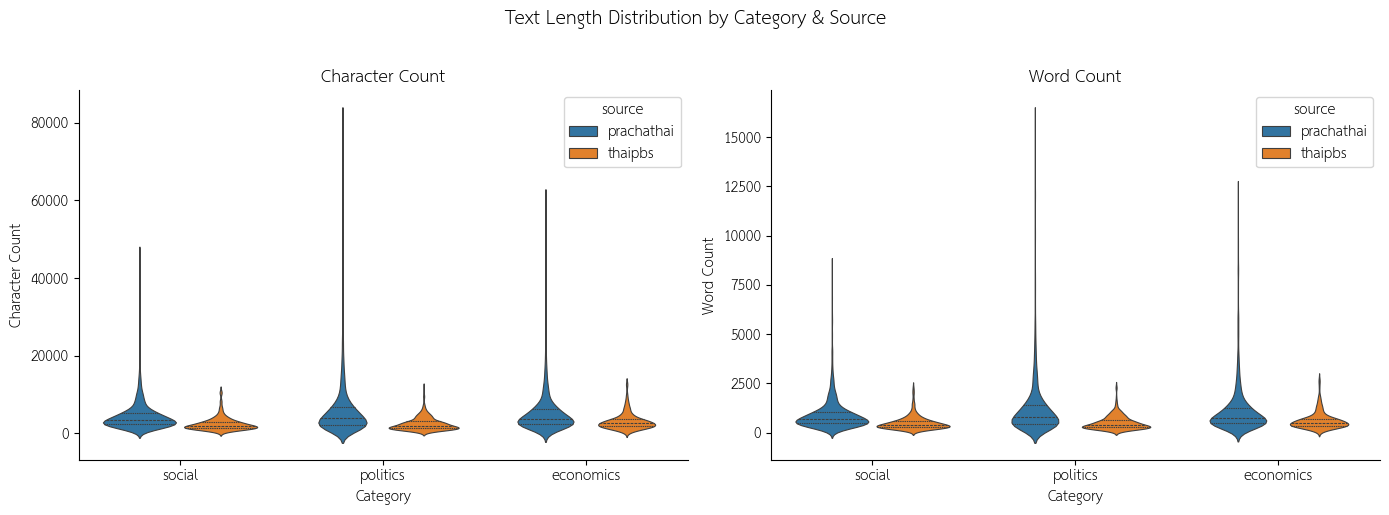

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, label in zip(
    axes,
    ["char_count", "word_count"],
    ["Character Count", "Word Count"],
):
    sns.violinplot(
        data=merged_df,
        x="category",
        y=metric,
        hue="source",
        inner="quart",
        linewidth=0.8,
        gap=0.1,
        ax=ax,
    )
    ax.set_title(label)
    ax.set_xlabel("Category")
    ax.set_ylabel(label)
    sns.despine(ax=ax)

plt.suptitle("Text Length Distribution by Category & Source", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Vocabulary Overlap Between Sources

เนื่องจาก 2 dataset มาจาก **ยุคสมัยและสำนักข่าวที่แตกต่างกัน** (Prachathai 2005–2018 vs ThaiPBS 2025–2026) เราจะตรวจสอบว่าคำศัพท์ที่ใช้บ่อยใน **หมวดเดียวกัน** ระหว่างสองแหล่งนั้นซ้ำกันมากแค่ไหน

เราจะใช้ **Jaccard Similarity** บน top-N คำบ่อย (หลังตัด stopwords) เป็นตัววัด:
$$J(A, B) = \frac{|A \cap B|}{|A \cup B|}$$

ถ้า Jaccard ต่ำ แสดงว่าคำศัพท์แต่ละยุคแตกต่างกันมาก ซึ่งเป็นเหตุผลสนับสนุนว่า **TF-IDF จะมีปัญหา** (feature space ไม่ตรงกัน) แต่ **Word Embeddings** จะจัดการได้ดีกว่าเพราะอิงความหมาย ไม่ใช่ตัวสะกดของคำ

In [27]:
from pythainlp.corpus.common import thai_stopwords
from collections import Counter

STOPWORDS = set(thai_stopwords())
TOP_N = 50
CATEGORIES = ["politics", "economics", "social"]

def top_words(texts, n=TOP_N):
    tokens = []
    for text in texts:
        words = tokenize(text)
        tokens.extend(
            w for w in words
            if w not in STOPWORDS and len(w.strip()) > 1 and not w.isdigit() and w.strip()
        )
    return Counter(tokens).most_common(n)

# Build frequency tables: freq_table[category][source] = [(word, count), ...]
freq_table = {}
for cat in CATEGORIES:
    freq_table[cat] = {}
    for src in ["prachathai", "thaipbs"]:
        texts = merged_df.loc[
            (merged_df["category"] == cat) & (merged_df["source"] == src), "body_text"
        ]
        freq_table[cat][src] = top_words(texts)
        print(f"  {cat}/{src}: tokenized {len(texts)} articles → top-{TOP_N} words computed")

  politics/prachathai: tokenized 1801 articles → top-50 words computed
  politics/thaipbs: tokenized 400 articles → top-50 words computed
  economics/prachathai: tokenized 1801 articles → top-50 words computed
  economics/thaipbs: tokenized 400 articles → top-50 words computed
  social/prachathai: tokenized 1801 articles → top-50 words computed
  social/thaipbs: tokenized 400 articles → top-50 words computed


In [28]:
def jaccard(set_a, set_b):
    return len(set_a & set_b) / len(set_a | set_b) if (set_a | set_b) else 0.0

rows = []
for cat in CATEGORIES:
    vocab_pct  = {w for w, _ in freq_table[cat]["prachathai"]}
    vocab_tpbs = {w for w, _ in freq_table[cat]["thaipbs"]}
    shared     = vocab_pct & vocab_tpbs
    rows.append({
        "category":        cat,
        "jaccard":         jaccard(vocab_pct, vocab_tpbs),
        "shared":          len(shared),
        "prachathai_only": len(vocab_pct  - vocab_tpbs),
        "thaipbs_only":    len(vocab_tpbs - vocab_pct),
    })

jaccard_df = pd.DataFrame(rows).set_index("category")
jaccard_df["jaccard"] = jaccard_df["jaccard"].map("{:.2%}".format)
jaccard_df

,jaccard,shared,prachathai_only,thaipbs_only
category,,,,
politics,29.87%,23,27,27
economics,31.58%,24,26,26
social,40.85%,29,21,21


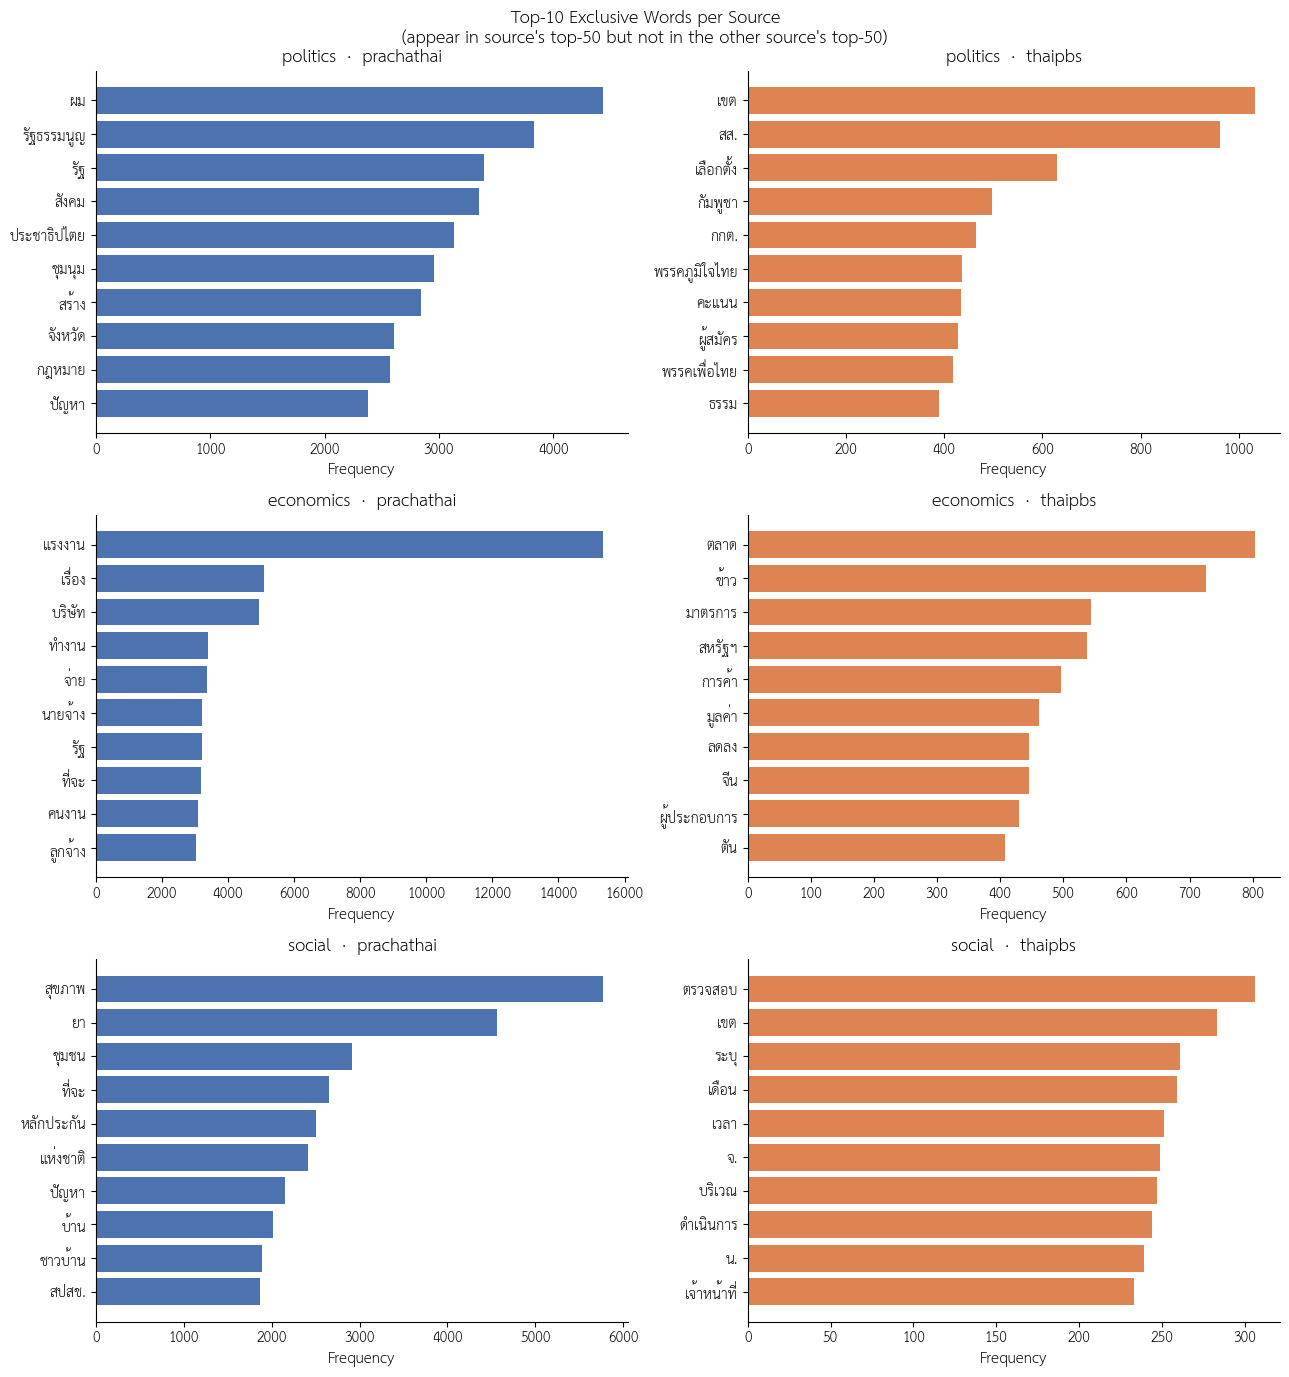

In [29]:
COLORS = {"prachathai": "#4C72B0", "thaipbs": "#DD8452"}
SOURCES = ["prachathai", "thaipbs"]

fig, axes = plt.subplots(3, 2, figsize=(13, 14))
fig.suptitle(
    f"Top-10 Exclusive Words per Source\n(appear in source's top-{TOP_N} but not in the other source's top-{TOP_N})",
    fontsize=12,
)

for row, cat in enumerate(CATEGORIES):
    vocab_pct  = dict(freq_table[cat]["prachathai"])
    vocab_tpbs = dict(freq_table[cat]["thaipbs"])
    exclusive  = {
        "prachathai": sorted(
            [(w, vocab_pct[w])  for w in set(vocab_pct)  - set(vocab_tpbs)],
            key=lambda x: x[1], reverse=True
        )[:10],
        "thaipbs": sorted(
            [(w, vocab_tpbs[w]) for w in set(vocab_tpbs) - set(vocab_pct)],
            key=lambda x: x[1], reverse=True
        )[:10],
    }

    for col, src in enumerate(SOURCES):
        ax = axes[row][col]
        items = exclusive[src]
        if not items:
            ax.text(0.5, 0.5, "No exclusive words", ha="center", va="center")
            continue
        words, counts = zip(*items)
        ax.barh(range(len(words)), counts, color=COLORS[src], edgecolor="none")
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words, fontsize=10)
        ax.invert_yaxis()
        ax.set_title(f"{cat}  ·  {src}", fontweight="bold")
        ax.set_xlabel("Frequency")
        sns.despine(ax=ax)

plt.tight_layout()
plt.show()

## สรุปผลการวิเคราะห์

### 1. ภาพรวม Dataset

| Dataset | จำนวนบทความ | ช่วงเวลา | รูปแบบ Label |
|---|---|---|---|
| **Prachathai67k** | 67,889 | 2004–2018 | Multi-label (12 หมวด) |
| **ThaiPBS** | 1,200 | 2025–2026 | Single-label (3 หมวด) |


---

### 2. การ Normalize Labels ของ Prachathai

เนื่องจาก Prachathai เป็น multi-label dataset เราจึงต้องกรองเฉพาะข่าวที่มีหมวดเดียวชัดเจน โดยอ้างอิงจาก Correlation Matrix ระหว่าง label
| หมวด | Label ที่รวมไว้ด้วยกัน | เหตุผล |
|---|---|---|
| **สังคม** | `social`, `quality_of_life` | corr = 0.43 (สูงสุด) |
| **เศรษฐกิจ** | `economics`, `labor`, `quality_of_life` | corr = 0.23–0.29, ไม่ซ้ำกับกลุ่มสังคม |
| **การเมือง** | `politics` เท่านั้น | เกี่ยวข้องกับทุกหมวด จึงดึงเฉพาะข่าวการเมืองล้วน ๆ |

ก่อน downsample มีจำนวน: สังคม 2,287 / เศรษฐกิจ 1,801 / การเมือง 24,341 บทความ  
หลัง downsample ที่ **1,801 บทความต่อหมวด** (ตามหมวดที่น้อยสุด) เพื่อป้องกัน bias ในการ train

---

### 3. Dataset หลังผสาน (Merged Dataset)

**จำนวนรวม: 6,603 บทความ**
- economics: 2,201  (prachathai 1,801 + thaipbs 400)
- politics: 2,201  (prachathai 1,801 + thaipbs 400)
- social: 2,201  (prachathai 1,801 + thaipbs 400)

**Category balanced** — metric อย่าง F1, Precision, Recall จึงใช้ได้อย่างถูกต้องโดยไม่ต้องปรับ class weight

---

### 4. Text Length Distribution

| Source | Median Word Count |
|---|---|
| Prachathai | ~700-800 คำ |
| ThaiPBS | ~400-500 คำ |


บทความ Prachathai ยาวกว่า ThaiPBS โดยเฉลี่ย **~2 เท่า** ความแตกต่างนี้เป็นไปตามที่คาด เนื่องจาก Prachathai เป็นสื่อเชิงวิเคราะห์/บทความยาว ขณะที่ ThaiPBS เป็นข่าวโทรทัศน์ที่กระชับกว่า

---

### 5. Vocabulary Overlap (Jaccard Similarity)

| หมวด | Jaccard | คำที่ซ้ำกัน | Prachathai เท่านั้น | ThaiPBS เท่านั้น |
|---|---|---|---|---|
| การเมือง | 29.87% | 23 | 27 | 27 |
| เศรษฐกิจ | 31.58% | 24 | 26 | 26 |
| สังคม | 40.85% | 29 | 21 | 21 |

คำศัพท์ที่ใช้มีบริบทต่างยุคสมัยชัดเจน:
- **การเมือง/Prachathai**: ผม, รัฐธรรมนูญ, ชุมนุม → สะท้อนยุคการเมืองปั่นป่วน 2548-2561
- **การเมือง/ThaiPBS**: เขต, ส.ส., เลือกตั้ง, กัมพูชา → เลือกตั้งและข่าวชายแดน 2568-2569
- **เศรษฐกิจ/Prachathai**: แรงงาน, นายจ้าง, ลูกจ้าง → เน้นปัญหาแรงงาน
- **เศรษฐกิจ/ThaiPBS**: ตลาด, ข้าว, สหรัฐฯ → การค้าและเกษตรระหว่างประเทศ

---

### 6. ผลกระทบต่อ Phase 3 (Classification)

| ปัญหา | ผลกระทบต่อ TF-IDF | ผลกระทบต่อ Word Embeddings |
|---|---|---|
| **Source imbalance** (4.5:1 prachathai:thaipbs) | สูง — vocabulary space ถูก dominate โดย Prachathai | ต่ำ-ปานกลาง |
| **Vocabulary divergence** (Jaccard ~30–40%) | สูง — feature ของ ThaiPBS มี IDF weight ต่ำ | ต่ำ — embeddings อิงความหมาย ไม่ใช่ตัวสะกด |
| **Text length gap** (~2x) | ปานกลาง | ปานกลาง — sequence modeling อาจได้เปรียบ |

**ข้อแนะนำสำหรับ Phase 3:**
- ทำ train/test split โดย **stratify ทั้ง `category` และ `source`** เพื่อให้ทั้งสอง source ปรากฏในทุก split
- รายงาน metric แยกตาม source ด้วย เพื่อเปรียบเทียบว่า TF-IDF และ Embeddings รับมือกับ domain shift ได้ต่างกันอย่างไร ซึ่งเป็น evidence สำคัญสำหรับ Error Analysis ใน Phase 4